In [1]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH)

db_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

job_postings = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            job_title_short,
            job_country,
            salary_year_avg
        FROM data_jobs.job_postings_fact
        """
    ),
    con=engine,
)

skills = pd.read_sql_query(
    sql=text(
        """
        SELECT
            skill_id,
            skills AS skill_name,
            type AS skill_type
        FROM data_jobs.skills_dim
        """
    ),
    con=engine,
)

job_skills = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            skill_id
        FROM data_jobs.skills_job_dim
        """
    ),
    con=engine,
)

print("Loaded DataFrames:")
print(f"- job_postings: {job_postings.shape[0]:,} rows × {job_postings.shape[1]} columns")
print(f"- skills: {skills.shape[0]:,} rows × {skills.shape[1]} columns")
print(f"- job_skills: {job_skills.shape[0]:,} rows × {job_skills.shape[1]} columns")

Loaded DataFrames:
- job_postings: 478,895 rows × 4 columns
- skills: 254 rows × 3 columns
- job_skills: 2,274,756 rows × 2 columns


In [ ]:

unique_country_counts = pd.read_sql_query(
    sql=text(
        """
        SELECT COUNT(DISTINCT job_country) AS unique_country_count
        FROM data_jobs.job_postings_fact
        WHERE job_country IS NOT NULL
        """
    ),
    con=engine,
)

display(unique_country_counts)

NameError: name 'job_postings_fact' is not defined

In [2]:
job_skills_quality_summary = pd.DataFrame(
    {
        "metric": [
            "job_skill_rows",
            "unique_job_skill_pairs",
            "duplicated_job_skill_pairs",
            "unique_jobs_with_at_least_one_skill",
            "unique_skills_assigned_to_at_least_one_job",
            "minimum_skills_per_job",
            "median_skills_per_job",
            "mean_skills_per_job",
            "maximum_skills_per_job",
        ],
        "value": [
            len(job_skills),
            job_skills.drop_duplicates(
                subset=["job_id", "skill_id"]
            ).shape[0],
            job_skills.duplicated(
                subset=["job_id", "skill_id"]
            ).sum(),
            job_skills["job_id"].nunique(),
            job_skills["skill_id"].nunique(),
            job_skills.groupby("job_id")["skill_id"].nunique().min(),
            job_skills.groupby("job_id")["skill_id"].nunique().median(),
            job_skills.groupby("job_id")["skill_id"].nunique().mean(),
            job_skills.groupby("job_id")["skill_id"].nunique().max(),
        ],
    }
)

display(job_skills_quality_summary)

jobs_with_skills = set(job_skills["job_id"])
jobs_without_skills = job_postings.loc[
    ~job_postings["job_id"].isin(jobs_with_skills)
].copy()

jobs_without_skills_summary = pd.DataFrame(
    {
        "metric": [
            "total_job_postings",
            "postings_with_at_least_one_skill",
            "postings_without_any_skill",
            "postings_without_any_skill_pct",
        ],
        "value": [
            len(job_postings),
            job_postings["job_id"].isin(jobs_with_skills).sum(),
            len(jobs_without_skills),
            round(
                len(jobs_without_skills)
                / len(job_postings)
                * 100,
                2,
            ),
        ],
    }
)

display(jobs_without_skills_summary)

,metric,value
0,job_skill_rows,"2,274,756.00"
1,unique_job_skill_pairs,"2,274,756.00"
2,duplicated_job_skill_pairs,0.00
3,unique_jobs_with_at_least_one_skill,"410,025.00"
4,unique_skills_assigned_to_at_least_one_job,254.00
5,minimum_skills_per_job,1.00
6,median_skills_per_job,5.00
7,mean_skills_per_job,5.55
8,maximum_skills_per_job,53.00


,metric,value
0,total_job_postings,"478,895.00"
1,postings_with_at_least_one_skill,"410,025.00"
2,postings_without_any_skill,"68,870.00"
3,postings_without_any_skill_pct,14.38


In [3]:
job_skill_detail = (
    job_skills
    .merge(
        job_postings,
        on="job_id",
        how="inner",
        validate="many_to_one",
    )
    .merge(
        skills,
        on="skill_id",
        how="inner",
        validate="many_to_one",
    )
)

join_validation_summary = pd.DataFrame(
    {
        "metric": [
            "job_skill_rows_before_join",
            "rows_after_join",
            "rows_lost_after_join",
            "unique_jobs_after_join",
            "unique_skills_after_join",
            "duplicate_job_skill_pairs_after_join",
        ],
        "value": [
            len(job_skills),
            len(job_skill_detail),
            len(job_skills) - len(job_skill_detail),
            job_skill_detail["job_id"].nunique(),
            job_skill_detail["skill_id"].nunique(),
            job_skill_detail.duplicated(
                subset=["job_id", "skill_id"]
            ).sum(),
        ],
    }
)

display(join_validation_summary)

display(job_skill_detail.head())

,metric,value
0,job_skill_rows_before_join,2274756
1,rows_after_join,2274756
2,rows_lost_after_join,0
3,unique_jobs_after_join,410025
4,unique_skills_after_join,254
5,duplicate_job_skill_pairs_after_join,0


,job_id,skill_id,job_title_short,job_country,salary_year_avg,skill_name,skill_type
0,5,0,Senior Data Scientist,United States,NaN,sql,programming
1,5,1,Senior Data Scientist,United States,NaN,python,programming
2,5,2,Senior Data Scientist,United States,NaN,r,programming
3,5,3,Senior Data Scientist,United States,NaN,c,programming
4,6,1,Machine Learning Engineer,United States,NaN,python,programming


In [4]:
skill_demand_profile = (
    job_skill_detail
    .groupby(
        [
            "skill_id",
            "skill_name",
            "skill_type",
        ],
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
    )
)

skill_demand_profile["share_of_skill_mapped_postings_pct"] = (
    skill_demand_profile["posting_count"]
    / job_skill_detail["job_id"].nunique()
    * 100
).round(2)

skill_demand_profile = skill_demand_profile.sort_values(
    by="posting_count",
    ascending=False,
).reset_index(drop=True)

skill_demand_threshold_summary = pd.DataFrame(
    {
        "minimum_posting_count": [
            10,
            25,
            50,
            100,
            250,
            500,
            1_000,
            2_500,
            5_000,
            10_000,
        ],
    }
)

skill_demand_threshold_summary["skills_meeting_threshold"] = (
    skill_demand_threshold_summary["minimum_posting_count"]
    .apply(
        lambda threshold: (
            skill_demand_profile["posting_count"] >= threshold
        ).sum()
    )
)

skill_demand_threshold_summary["share_of_all_skills_pct"] = (
    skill_demand_threshold_summary["skills_meeting_threshold"]
    / len(skill_demand_profile)
    * 100
).round(2)

print("Top 30 skills by posting count:")
display(skill_demand_profile.head(30))

print("\nSkill-count threshold profile:")
display(skill_demand_threshold_summary)

Top 30 skills by posting count:


,skill_id,skill_name,skill_type,posting_count,share_of_skill_mapped_postings_pct
0,1,python,programming,244416,59.61
1,0,sql,programming,240179,58.58
2,75,aws,cloud,100386,24.48
3,78,azure,cloud,93849,22.89
4,178,tableau,analyst_tools,73560,17.94
5,94,spark,libraries,71979,17.55
6,2,r,programming,71835,17.52
7,177,excel,analyst_tools,71807,17.51
8,182,power bi,analyst_tools,66183,16.14
9,8,java,programming,51294,12.51



Skill-count threshold profile:


,minimum_posting_count,skills_meeting_threshold,share_of_all_skills_pct
0,10,236,92.91
1,25,226,88.98
2,50,212,83.46
3,100,196,77.17
4,250,170,66.93
5,500,146,57.48
6,1000,130,51.18
7,2500,97,38.19
8,5000,74,29.13
9,10000,52,20.47


In [5]:
COOCCURRENCE_MIN_SKILL_POSTINGS = 5_000

cooccurrence_skills = skill_demand_profile.loc[
    skill_demand_profile["posting_count"] >= COOCCURRENCE_MIN_SKILL_POSTINGS,
    [
        "skill_id",
        "skill_name",
        "skill_type",
        "posting_count",
    ],
].copy()

cooccurrence_job_skills = job_skill_detail.loc[
    job_skill_detail["skill_id"].isin(
        cooccurrence_skills["skill_id"]
    ),
    [
        "job_id",
        "skill_id",
        "skill_name",
    ],
].copy()

cooccurrence_preparation_summary = pd.DataFrame(
    {
        "metric": [
            "minimum_posting_count_for_skill",
            "skills_selected_for_cooccurrence",
            "job_skill_rows_for_selected_skills",
            "unique_jobs_with_selected_skills",
            "share_of_all_skill_mapped_jobs_pct",
        ],
        "value": [
            COOCCURRENCE_MIN_SKILL_POSTINGS,
            cooccurrence_skills["skill_id"].nunique(),
            len(cooccurrence_job_skills),
            cooccurrence_job_skills["job_id"].nunique(),
            round(
                cooccurrence_job_skills["job_id"].nunique()
                / job_skill_detail["job_id"].nunique()
                * 100,
                2,
            ),
        ],
    }
)

print("Skills selected for co-occurrence analysis:")
display(cooccurrence_skills)

print("\nCo-occurrence preparation summary:")
display(cooccurrence_preparation_summary)

Skills selected for co-occurrence analysis:


,skill_id,skill_name,skill_type,posting_count
0,1,python,programming,244416
1,0,sql,programming,240179
2,75,aws,cloud,100386
3,78,azure,cloud,93849
4,178,tableau,analyst_tools,73560
...,...,...,...,...
69,103,react,libraries,5381
70,62,elasticsearch,databases,5379
71,110,gdpr,libraries,5373
72,25,t-sql,programming,5176



Co-occurrence preparation summary:


,metric,value
0,minimum_posting_count_for_skill,"5,000.00"
1,skills_selected_for_cooccurrence,74.00
2,job_skill_rows_for_selected_skills,"2,115,223.00"
3,unique_jobs_with_selected_skills,"405,631.00"
4,share_of_all_skill_mapped_jobs_pct,98.93


In [6]:
from itertools import combinations

job_to_skills = (
    cooccurrence_job_skills
    .groupby("job_id")["skill_name"]
    .apply(lambda values: sorted(set(values)))
)

cooccurrence_pairs = []

for skill_list in job_to_skills:
    if len(skill_list) >= 2:
        cooccurrence_pairs.extend(
            combinations(skill_list, 2)
        )

cooccurrence_pairs = pd.DataFrame(
    cooccurrence_pairs,
    columns=[
        "skill_name_1",
        "skill_name_2",
    ],
)

cooccurrence_pair_counts = (
    cooccurrence_pairs
    .value_counts()
    .rename("cooccurrence_count")
    .reset_index()
)

cooccurrence_pair_counts = cooccurrence_pair_counts.sort_values(
    by="cooccurrence_count",
    ascending=False,
).reset_index(drop=True)

cooccurrence_pair_counts["share_of_selected_skill_jobs_pct"] = (
    cooccurrence_pair_counts["cooccurrence_count"]
    / cooccurrence_job_skills["job_id"].nunique()
    * 100
).round(2)

cooccurrence_pair_summary = pd.DataFrame(
    {
        "metric": [
            "selected_skills",
            "jobs_with_selected_skills",
            "unique_skill_pairs",
            "highest_pair_cooccurrence_count",
            "median_pair_cooccurrence_count",
        ],
        "value": [
            cooccurrence_skills["skill_id"].nunique(),
            cooccurrence_job_skills["job_id"].nunique(),
            len(cooccurrence_pair_counts),
            cooccurrence_pair_counts["cooccurrence_count"].max(),
            cooccurrence_pair_counts["cooccurrence_count"].median(),
        ],
    }
)

display(cooccurrence_pair_summary)

print("\nTop 30 co-occurring skill pairs:")
display(cooccurrence_pair_counts.head(30))

,metric,value
0,selected_skills,74.00
1,jobs_with_selected_skills,"405,631.00"
2,unique_skill_pairs,"2,555.00"
3,highest_pair_cooccurrence_count,"166,315.00"
4,median_pair_cooccurrence_count,753.00



Top 30 co-occurring skill pairs:


,skill_name_1,skill_name_2,cooccurrence_count,share_of_selected_skill_jobs_pct
0,python,sql,166315,41.00
1,aws,python,77557,19.12
2,python,r,66585,16.42
3,azure,python,65869,16.24
4,aws,sql,64331,15.86
5,azure,sql,63776,15.72
6,python,spark,59322,14.62
7,sql,tableau,57407,14.15
8,r,sql,51222,12.63
9,spark,sql,49928,12.31


In [7]:
skill_posting_counts = (
    cooccurrence_skills
    .set_index("skill_name")["posting_count"]
    .to_dict()
)

total_selected_skill_jobs = cooccurrence_job_skills["job_id"].nunique()

cooccurrence_pair_metrics = cooccurrence_pair_counts.copy()

cooccurrence_pair_metrics["skill_1_posting_count"] = (
    cooccurrence_pair_metrics["skill_name_1"]
    .map(skill_posting_counts)
)

cooccurrence_pair_metrics["skill_2_posting_count"] = (
    cooccurrence_pair_metrics["skill_name_2"]
    .map(skill_posting_counts)
)

cooccurrence_pair_metrics["confidence_skill_1_to_skill_2_pct"] = (
    cooccurrence_pair_metrics["cooccurrence_count"]
    / cooccurrence_pair_metrics["skill_1_posting_count"]
    * 100
).round(2)

cooccurrence_pair_metrics["confidence_skill_2_to_skill_1_pct"] = (
    cooccurrence_pair_metrics["cooccurrence_count"]
    / cooccurrence_pair_metrics["skill_2_posting_count"]
    * 100
).round(2)

cooccurrence_pair_metrics["lift"] = (
    cooccurrence_pair_metrics["cooccurrence_count"]
    * total_selected_skill_jobs
    / (
        cooccurrence_pair_metrics["skill_1_posting_count"]
        * cooccurrence_pair_metrics["skill_2_posting_count"]
    )
).round(3)

top_pairs_by_count = (
    cooccurrence_pair_metrics
    .sort_values(
        by="cooccurrence_count",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

top_pairs_by_lift = (
    cooccurrence_pair_metrics
    .loc[
        cooccurrence_pair_metrics["cooccurrence_count"] >= 1_000
    ]
    .sort_values(
        by="lift",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

print("Top 20 pairs by absolute co-occurrence count:")
display(
    top_pairs_by_count[
        [
            "skill_name_1",
            "skill_name_2",
            "cooccurrence_count",
            "share_of_selected_skill_jobs_pct",
            "confidence_skill_1_to_skill_2_pct",
            "confidence_skill_2_to_skill_1_pct",
            "lift",
        ]
    ]
)

print("\nTop 20 pairs by lift, with at least 1,000 co-occurrences:")
display(
    top_pairs_by_lift[
        [
            "skill_name_1",
            "skill_name_2",
            "cooccurrence_count",
            "share_of_selected_skill_jobs_pct",
            "confidence_skill_1_to_skill_2_pct",
            "confidence_skill_2_to_skill_1_pct",
            "lift",
        ]
    ]
)

Top 20 pairs by absolute co-occurrence count:


,skill_name_1,skill_name_2,cooccurrence_count,share_of_selected_skill_jobs_pct,confidence_skill_1_to_skill_2_pct,confidence_skill_2_to_skill_1_pct,lift
0,python,sql,166315,41.00,68.05,69.25,1.15
1,aws,python,77557,19.12,77.26,31.73,1.28
2,python,r,66585,16.42,27.24,92.69,1.54
3,azure,python,65869,16.24,70.19,26.95,1.17
4,aws,sql,64331,15.86,64.08,26.78,1.08
5,azure,sql,63776,15.72,67.96,26.55,1.15
6,python,spark,59322,14.62,24.27,82.42,1.37
7,sql,tableau,57407,14.15,23.90,78.04,1.32
8,r,sql,51222,12.63,71.31,21.33,1.20
9,spark,sql,49928,12.31,69.36,20.79,1.17



Top 20 pairs by lift, with at least 1,000 co-occurrences:


,skill_name_1,skill_name_2,cooccurrence_count,share_of_selected_skill_jobs_pct,confidence_skill_1_to_skill_2_pct,confidence_skill_2_to_skill_1_pct,lift
0,confluence,jira,5551,1.37,84.96,40.39,25.07
1,matplotlib,numpy,3365,0.83,57.50,26.47,18.35
2,numpy,pandas,11581,2.86,91.11,57.16,18.24
3,outlook,word,3520,0.87,68.02,22.55,17.68
4,keras,tensorflow,5947,1.47,84.57,24.48,14.12
5,cassandra,mongodb,2627,0.65,36.55,24.53,13.84
6,ssis,t-sql,1783,0.44,17.50,34.45,13.71
7,outlook,powerpoint,2437,0.60,47.09,17.47,13.69
8,sas,spss,3580,0.88,18.32,65.27,13.55
9,pytorch,tensorflow,17401,4.29,81.06,71.62,13.53


In [11]:
import numpy as np


HEATMAP_TOP_N_SKILLS = 20

heatmap_skills = (
    cooccurrence_skills
    .sort_values(
        by="posting_count",
        ascending=False,
    )
    .head(HEATMAP_TOP_N_SKILLS)
    .copy()
)

heatmap_skill_names = heatmap_skills["skill_name"].tolist()

heatmap_job_skills = (
    cooccurrence_job_skills
    .loc[
        cooccurrence_job_skills["skill_name"].isin(
            heatmap_skill_names
        ),
        [
            "job_id",
            "skill_name",
        ],
    ]
    .drop_duplicates()
)

heatmap_job_skill_matrix = (
    heatmap_job_skills
    .assign(present=1)
    .pivot_table(
        index="job_id",
        columns="skill_name",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
)

heatmap_skill_order = heatmap_skills["skill_name"].tolist()

heatmap_job_skill_matrix = heatmap_job_skill_matrix.reindex(
    columns=heatmap_skill_order,
    fill_value=0,
)

cooccurrence_matrix = (
    heatmap_job_skill_matrix.T
    .dot(heatmap_job_skill_matrix)
)

cooccurrence_matrix.index.name = "skill_name"
cooccurrence_matrix.columns.name = "skill_name"

heatmap_matrix_summary = pd.DataFrame(
    {
        "metric": [
            "skills_in_heatmap",
            "jobs_in_heatmap_input",
            "matrix_rows",
            "matrix_columns",
            "highest_off_diagonal_cooccurrence",
        ],
        "value": [
            len(heatmap_skill_order),
            len(heatmap_job_skill_matrix),
            cooccurrence_matrix.shape[0],
            cooccurrence_matrix.shape[1],
            (
                cooccurrence_matrix
                .where(
                    ~pd.DataFrame(
                        np.eye(
                            len(cooccurrence_matrix),
                            dtype=bool,
                        ),
                        index=cooccurrence_matrix.index,
                        columns=cooccurrence_matrix.columns,
                    )
                )
                .max()
                .max()
            ),
        ],
    }
)

display(heatmap_matrix_summary)

display(cooccurrence_matrix)

,metric,value
0,skills_in_heatmap,20.00
1,jobs_in_heatmap_input,"386,653.00"
2,matrix_rows,20.00
3,matrix_columns,20.00
4,highest_off_diagonal_cooccurrence,"166,315.00"


skill_name,python,sql,aws,azure,tableau,spark,r,excel,power bi,java,databricks,snowflake,hadoop,gcp,scala,airflow,kafka,git,nosql,docker
skill_name,,,,,,,,,,,,,,,,,,,,
python,244416,166315,77557,65869,48327,59322,66585,24890,35116,42976,31939,29601,30117,29005,31196,28883,24326,24526,22548,23066
sql,166315,240179,64331,63776,57407,49928,51222,37103,48692,31467,30720,31963,27041,23768,24369,25574,20712,20772,23505,14835
aws,77557,64331,100386,44386,15126,34529,14444,4812,9925,22275,15569,21983,17418,24026,17820,18487,17501,12513,15382,14925
azure,65869,63776,44386,93849,12149,29944,13006,4974,18586,17494,29177,16161,14395,20878,15537,9315,13445,11599,12563,10349
tableau,48327,57407,15126,12149,73560,10459,24257,20019,31108,7037,5925,9103,7322,5083,4256,5460,3275,3956,4325,3168
spark,59322,49928,34529,29944,10459,71979,13025,3005,7893,21805,17977,11795,29872,12555,24509,15092,21377,9021,14741,9327
r,66585,51222,14444,13006,24257,13025,71835,12223,16296,9169,4946,4203,8782,4622,7029,2244,2667,4470,4702,2847
excel,24890,37103,4812,4974,20019,3005,12223,71807,19616,2755,2189,2858,1854,1570,1382,1287,776,1480,1392,912
power bi,35116,48692,9925,18586,31108,7893,16296,19616,66183,4167,7944,6280,4011,3170,3026,2736,2182,2946,2945,1370


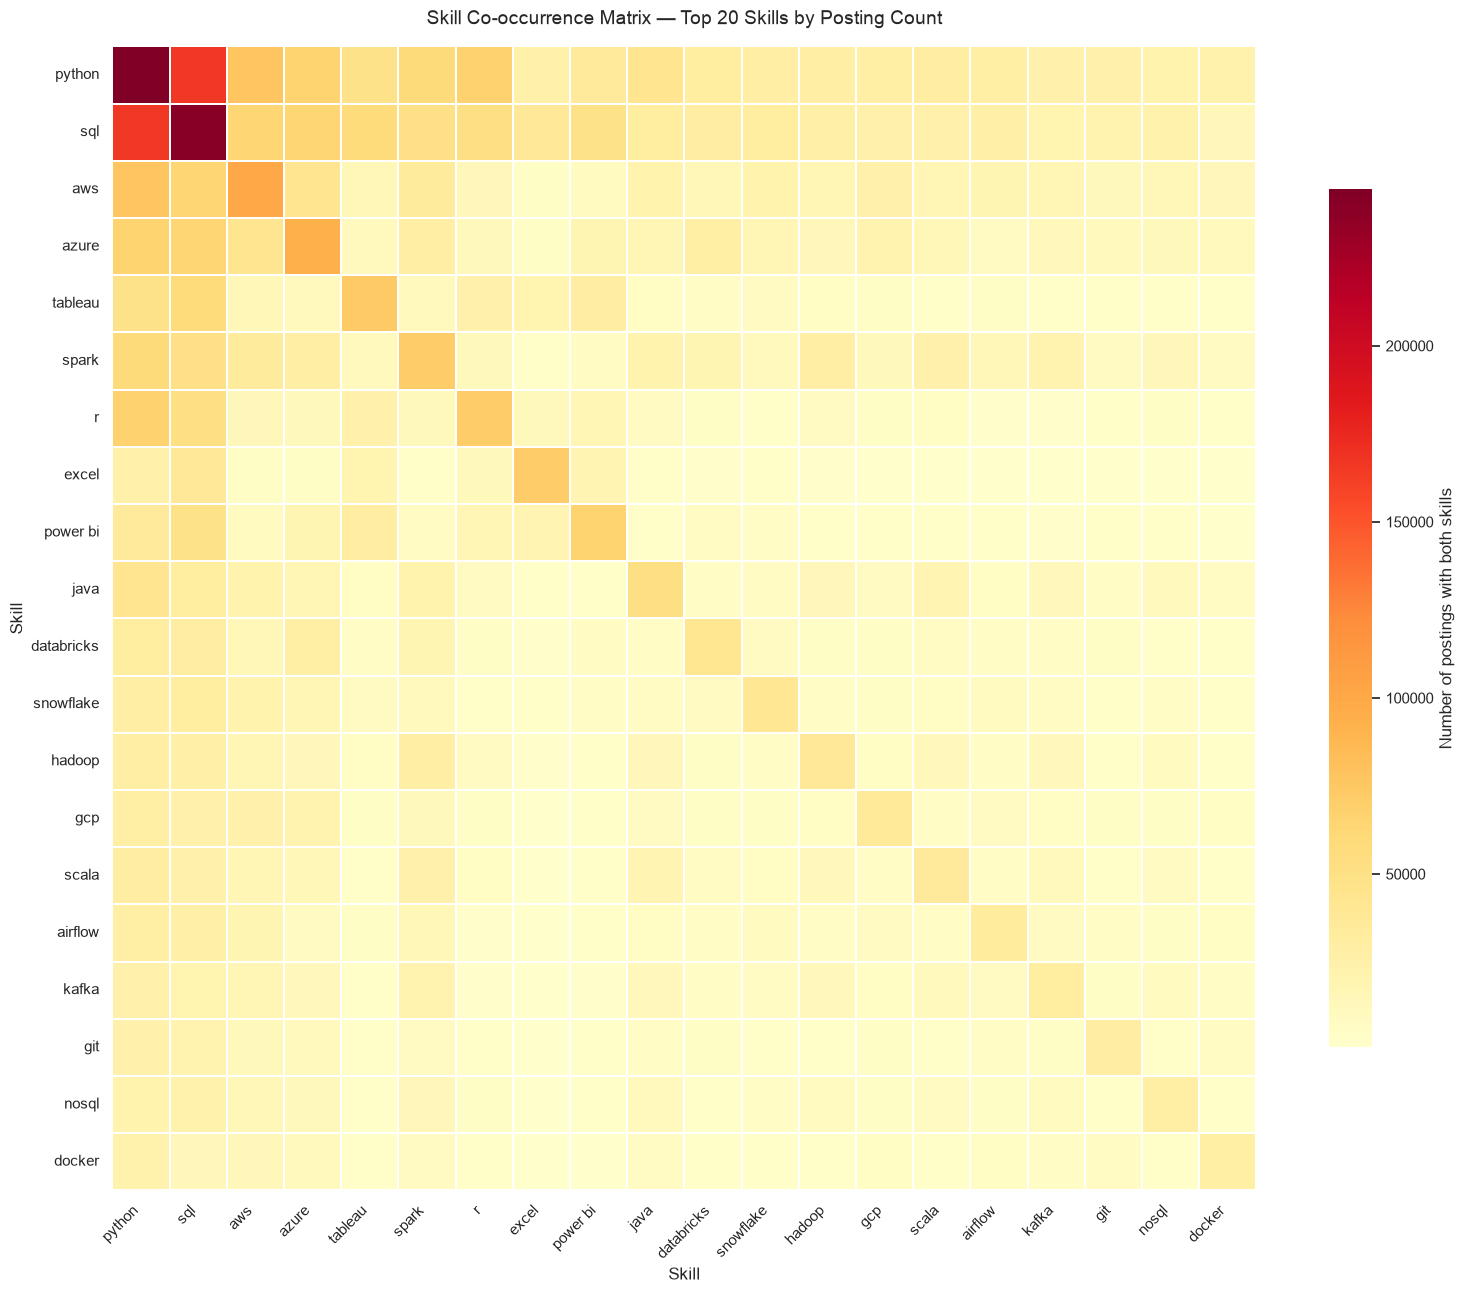

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")

plt.figure(figsize=(16, 13))

sns.heatmap(
    cooccurrence_matrix,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Number of postings with both skills",
        "shrink": 0.75,
    },
)

plt.title(
    "Skill Co-occurrence Matrix — Top 20 Skills by Posting Count",
    fontsize=14,
    pad=16,
)

plt.xlabel("Skill")
plt.ylabel("Skill")

plt.xticks(
    rotation=45,
    ha="right",
)

plt.yticks(
    rotation=0,
)

plt.tight_layout()
plt.show()